In [6]:
import sys
!{sys.executable} -m pip install pandas matplotlib scikit-learn


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:

import pandas as pd
# import matplotlib.pyplot as plt
# from sklearn.model_selection import train_test_split
#from sklearn.linear_model import LogisticRegression
# from sklearn.metrics import accuracy_score

# ---- LOAD DATA ----
df = pd.read_csv("students.csv")

# ---- 1. FIRST 5 ROWS ----
print("First 5 rows:\n")
print(df.head())

# ---- 2. SHAPE + DTYPES ----
print("\nShape (rows, columns):", df.shape)

print("\nData Types:\n")
print(df.dtypes)

# ---- 3. SUMMARY STATISTICS ----
print("\nSummary Statistics:\n")
print(df.describe())

# ---- 4. PASS / FAIL COUNT ----
print("\nPass / Fail Count:\n")
print(df["passed"].value_counts())

# ---- 5. AVERAGE SUBJECT SCORES ----
subject_cols = ["math", "science", "english", "history", "pe"]

# Passing students
pass_avg = df[df["passed"] == 1][subject_cols].mean()

# Failing students
fail_avg = df[df["passed"] == 0][subject_cols].mean()

print("\nAverage Scores (Passed):\n", pass_avg)
print("\nAverage Scores (Failed):\n", fail_avg)

# ---- 6. TOP STUDENT ----
df["avg"] = df[subject_cols].mean(axis=1)

top_student = df.loc[df["avg"].idxmax()]

print("\nTop Student:")
print(top_student["name"], "-", round(top_student["avg"], 2))

First 5 rows:

      name  math  science  english  history  pe  attendance_pct  \
0    Alice    88       92       76       80  95              92   
1      Bob    42       55       48       50  60              65   
2  Charlie    75       70       80       68  88              85   
3    Diana    95       98       91       89  97              98   
4      Eve    38       42       50       45  55              58   

   study_hours_per_day  passed  
0                  4.5       1  
1                  1.2       0  
2                  3.0       1  
3                  6.0       1  
4                  0.8       0  

Shape (rows, columns): (15, 9)

Data Types:

name                       str
math                     int64
science                  int64
english                  int64
history                  int64
pe                       int64
attendance_pct           int64
study_hours_per_day    float64
passed                   int64
dtype: object

Summary Statistics:

            math    sci

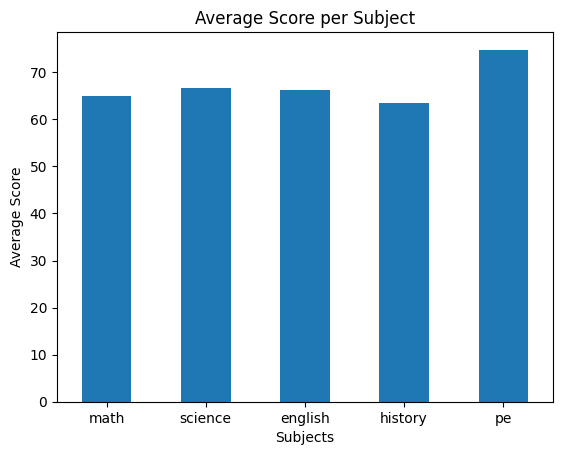

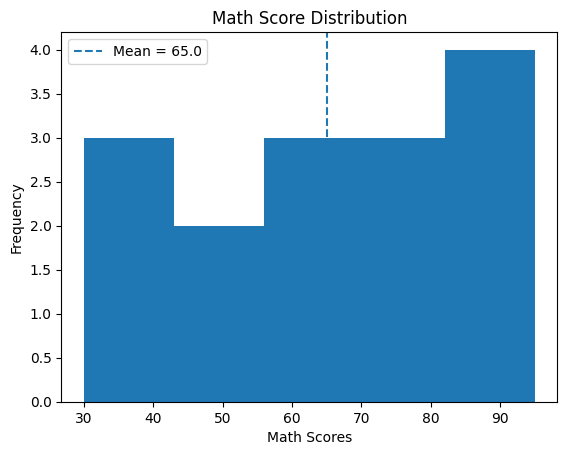

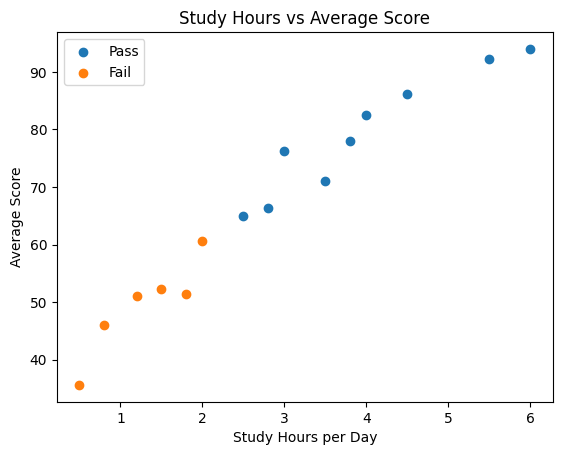

C:\Users\Santosh\AppData\Local\Temp\ipykernel_28004\2953634182.py:69: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])


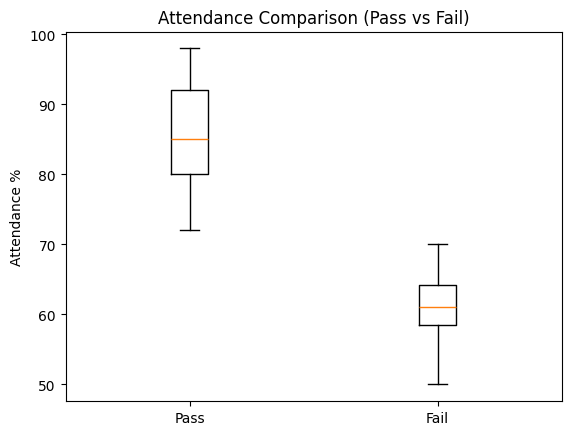

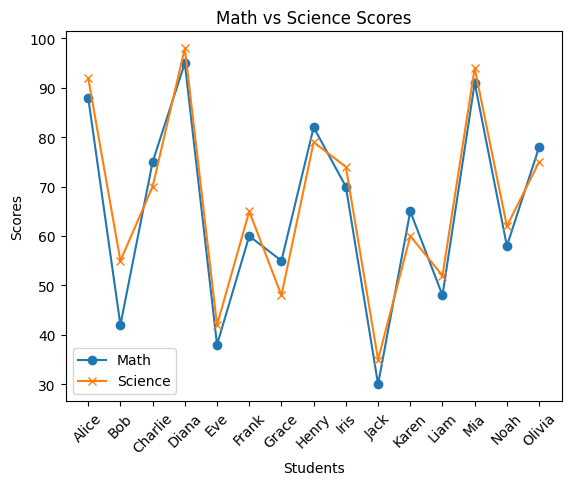

In [4]:
import pandas as pd
import matplotlib.pyplot as plt

# ---- LOAD DATA ----
df = pd.read_csv("students.csv")

# ---- ADD AVG SCORE COLUMN ----
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# =========================================================
# ✅ 1. BAR CHART — Average score per subject
# =========================================================
avg_scores = df[subject_cols].mean()

plt.figure()
avg_scores.plot(kind='bar')
plt.title("Average Score per Subject")
plt.xlabel("Subjects")
plt.ylabel("Average Score")
plt.xticks(rotation=0)
plt.savefig("plot1_bar.png")
plt.show()


# =========================================================
# ✅ 2. HISTOGRAM — Math score distribution
# =========================================================
plt.figure()
plt.hist(df['math'], bins=5)
mean_math = df['math'].mean()

plt.axvline(mean_math, linestyle='dashed', label=f"Mean = {round(mean_math,2)}")
plt.title("Math Score Distribution")
plt.xlabel("Math Scores")
plt.ylabel("Frequency")
plt.legend()
plt.savefig("plot2_hist.png")
plt.show()


# =========================================================
# ✅ 3. SCATTER — Study Hours vs Avg Score
# =========================================================
plt.figure()

pass_data = df[df['passed'] == 1]
fail_data = df[df['passed'] == 0]

plt.scatter(pass_data['study_hours_per_day'], pass_data['avg_score'], label="Pass")
plt.scatter(fail_data['study_hours_per_day'], fail_data['avg_score'], label="Fail")

plt.title("Study Hours vs Average Score")
plt.xlabel("Study Hours per Day")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot3_scatter.png")
plt.show()


# =========================================================
# ✅ 4. BOX PLOT — Attendance comparison
# =========================================================
pass_attendance = df[df['passed'] == 1]['attendance_pct'].tolist()
fail_attendance = df[df['passed'] == 0]['attendance_pct'].tolist()

plt.figure()
plt.boxplot([pass_attendance, fail_attendance], labels=["Pass", "Fail"])
plt.title("Attendance Comparison (Pass vs Fail)")
plt.ylabel("Attendance %")
plt.savefig("plot4_box.png")
plt.show()


# =========================================================
# ✅ 5. LINE PLOT — Math vs Science
# =========================================================
plt.figure()

plt.plot(df['name'], df['math'], marker='o', label="Math")
plt.plot(df['name'], df['science'], marker='x', label="Science")

plt.title("Math vs Science Scores")
plt.xlabel("Students")
plt.ylabel("Scores")
plt.xticks(rotation=45)
plt.legend()
plt.savefig("plot5_line.png")
plt.show()


[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


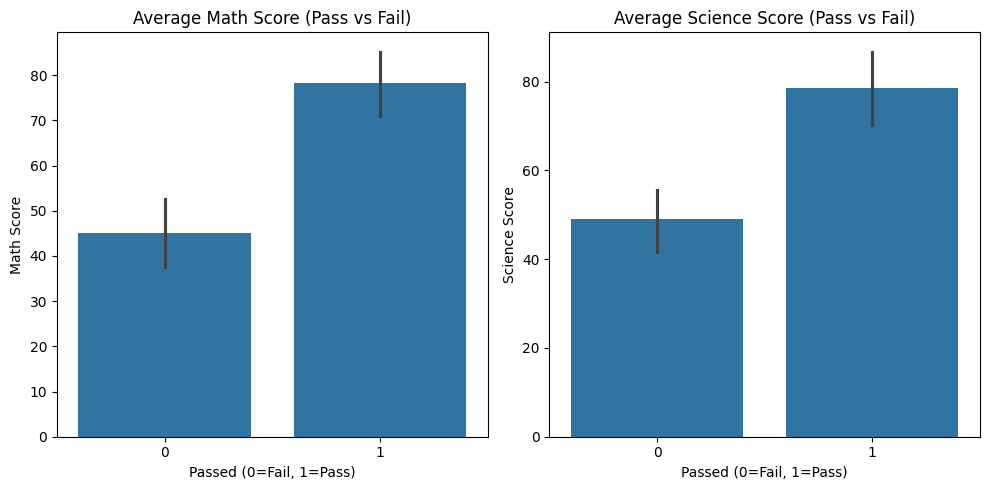

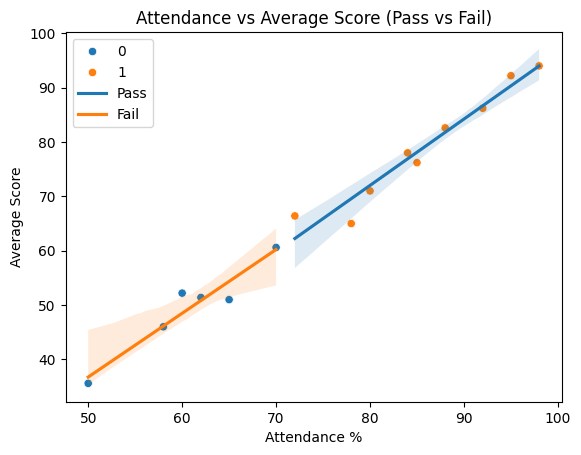

In [3]:
# Task 3 Data Visualization with Seaborn

import sys
!{sys.executable} -m pip install seaborn
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---- LOAD DATA ----
df = pd.read_csv("students.csv")

# ---- ADD AVG SCORE ----
subject_cols = ['math', 'science', 'english', 'history', 'pe']
df['avg_score'] = df[subject_cols].mean(axis=1)


# =========================================================
# ✅ 1. SEABORN BAR PLOTS (Math & Science by Pass/Fail)
# =========================================================
plt.figure(figsize=(10, 5))

# Subplot 1: Math
ax1 = plt.subplot(1, 2, 1)
sns.barplot(data=df, x='passed', y='math', ax=ax1)
ax1.set_title("Average Math Score (Pass vs Fail)")
ax1.set_xlabel("Passed (0=Fail, 1=Pass)")
ax1.set_ylabel("Math Score")

# Subplot 2: Science
ax2 = plt.subplot(1, 2, 2)
sns.barplot(data=df, x='passed', y='science', ax=ax2)
ax2.set_title("Average Science Score (Pass vs Fail)")
ax2.set_xlabel("Passed (0=Fail, 1=Pass)")
ax2.set_ylabel("Science Score")

plt.tight_layout()
plt.savefig("plot6_seaborn_bar.png")
plt.show()


# =========================================================
# ✅ 2. SEABORN SCATTER + REGRESSION
# =========================================================
plt.figure()

# Scatter
sns.scatterplot(data=df, x='attendance_pct', y='avg_score', hue='passed')

# Regression lines (separate for Pass and Fail)
sns.regplot(
    data=df[df['passed'] == 1],
    x='attendance_pct',
    y='avg_score',
    label='Pass',
    scatter=False
)

sns.regplot(
    data=df[df['passed'] == 0],
    x='attendance_pct',
    y='avg_score',
    label='Fail',
    scatter=False
)

plt.title("Attendance vs Average Score (Pass vs Fail)")
plt.xlabel("Attendance %")
plt.ylabel("Average Score")
plt.legend()
plt.savefig("plot7_seaborn_scatter.png")
plt.show()


# =========================================================
# 📝 COMMENT (for assignment)
# =========================================================
# Seaborn made it easier to create attractive and informative plots with less code,
# especially for grouped data like pass vs fail. Compared to Matplotlib, Seaborn
# automatically handles styling and aggregation, reducing manual effort.

Training Accuracy: 1.0
Test Accuracy: 1.0

Test Predictions:

Jack: Actual=0, Predicted=0 → ✅ Correct
Liam: Actual=0, Predicted=0 → ✅ Correct
Alice: Actual=1, Predicted=1 → ✅ Correct

Feature Importance:

english: 0.813
attendance_pct: 0.522
study_hours_per_day: 0.484
pe: 0.475
math: 0.438
science: 0.323
history: 0.263


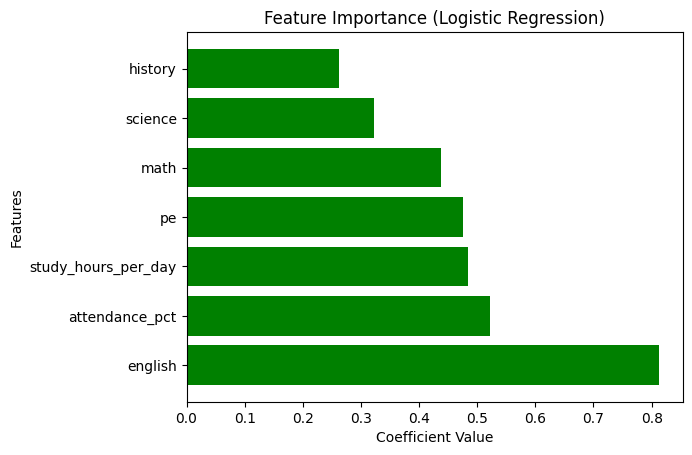

In [4]:

# Task 4: Machine Learning
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# ---- LOAD DATA ----
df = pd.read_csv("students.csv")

# ---- FEATURES & TARGET ----
features = ["math", "science", "english", "history", "pe", "attendance_pct", "study_hours_per_day"]
X = df[features]
y = df["passed"]

# ---- TRAIN TEST SPLIT ----
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ---- SCALING ----
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# =========================================================
# ✅ STEP 2 — TRAIN MODEL
# =========================================================
model = LogisticRegression()
model.fit(X_train_scaled, y_train)

train_acc = model.score(X_train_scaled, y_train)
print("Training Accuracy:", train_acc)


# =========================================================
# ✅ STEP 3 — EVALUATE MODEL
# =========================================================
y_pred = model.predict(X_test_scaled)

test_acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", test_acc)

print("\nTest Predictions:\n")

# Print name + actual + predicted
for i, pred in enumerate(y_pred):
    idx = X_test.index[i]
    name = df.loc[idx, "name"]
    actual = y_test.iloc[i]

    if pred == actual:
        status = "✅ Correct"
    else:
        status = "❌ Wrong"

    print(f"{name}: Actual={actual}, Predicted={pred} → {status}")


# =========================================================
# ✅ STEP 4 — FEATURE IMPORTANCE
# =========================================================
coefficients = model.coef_[0]

# Pair with feature names
feature_importance = list(zip(features, coefficients))

# Sort by absolute value
feature_importance.sort(key=lambda x: abs(x[1]), reverse=True)

print("\nFeature Importance:\n")
for f, c in feature_importance:
    print(f"{f}: {round(c, 3)}")

# ---- PLOT ----
names = [f for f, c in feature_importance]
values = [c for f, c in feature_importance]

# Colors: green (positive), red (negative)
colors = ["green" if v > 0 else "red" for v in values]

plt.figure()
plt.barh(names, values)
for i in range(len(values)):
    plt.barh(names[i], values[i], color=colors[i])

plt.title("Feature Importance (Logistic Regression)")
plt.xlabel("Coefficient Value")
plt.ylabel("Features")
plt.savefig("plot8_feature_importance.png")
plt.show()


# =========================================================
